In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
tickers = ['NVDA', 'QQQ']
data = yf.download(tickers, start='2020-01-01')['Close']

nvda = data['NVDA']
qqq = data['QQQ']

/tmp/ipykernel_2975/1204168195.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2020-01-01')['Close']
[*********************100%***********************]  2 of 2 completed


In [3]:
spread = nvda / qqq

In [4]:
window = 25

rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()

z_score = (spread - rolling_mean) / rolling_std

In [5]:
ema_50 = nvda.ewm(span=50).mean()
trend_filter = nvda > ema_50

In [6]:
signals = pd.DataFrame(index=spread.index)

signals['z'] = z_score
signals['long_entry'] = (z_score < -1.5) & trend_filter
signals['strong_entry'] = (z_score < -2.5) & trend_filter

In [7]:
returns = []
holding_period = 7

for i in range(len(signals) - holding_period):
    if signals['long_entry'].iloc[i]:
        entry_price = nvda.iloc[i]

        for j in range(1, holding_period + 1):
            exit_idx = i + j

            # exit on mean reversion
            if z_score.iloc[exit_idx] > -0.5:
                exit_price = nvda.iloc[exit_idx]
                break
        else:
            # forced exit
            exit_price = nvda.iloc[i + holding_period]

        ret = (exit_price - entry_price) / entry_price
        returns.append(ret)

In [8]:
returns = pd.Series(returns)

win_rate = (returns > 0).mean()
avg_return = returns.mean()
max_drawdown = returns.min()
sharpe = returns.mean() / returns.std()

print("Win Rate:", round(win_rate, 3))
print("Average Return:", round(avg_return, 4))
print("Max Drawdown:", round(max_drawdown, 4))
print("Sharpe Ratio:", round(sharpe, 2))

Win Rate: 0.821
Average Return: 0.0296
Max Drawdown: -0.0713
Sharpe Ratio: 0.82


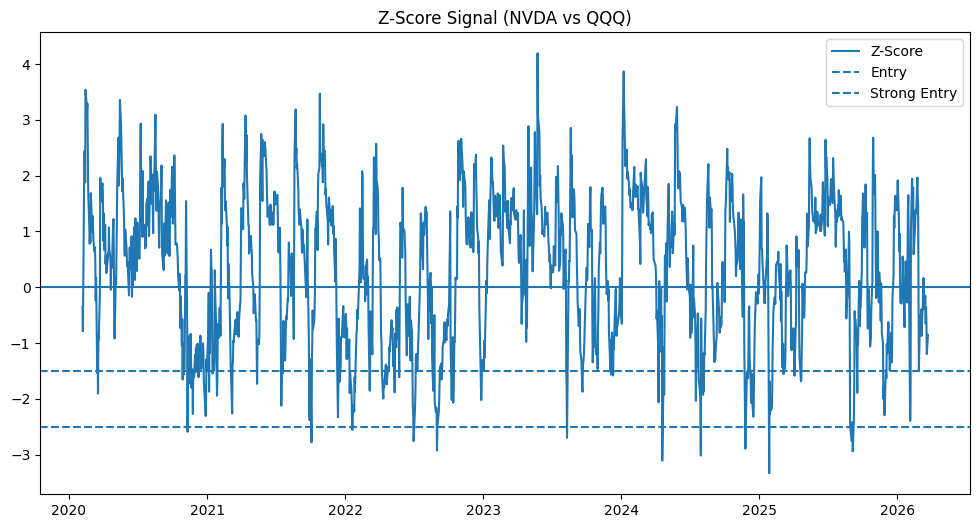

In [9]:
plt.figure(figsize=(12,6))

plt.plot(z_score, label='Z-Score')
plt.axhline(-1.5, linestyle='--', label='Entry')
plt.axhline(-2.5, linestyle='--', label='Strong Entry')
plt.axhline(0, linestyle='-')

plt.title('Z-Score Signal (NVDA vs QQQ)')
plt.legend()
plt.show()